# M2A4 — Solução do desafio: **Quem Extrai Mais Performance?**

Este notebook foi preparado como **solução de apresentação em aula** para o desafio em grupo do Módulo 2, Aula 4.

## Objetivo
Comparar abordagens diferentes para o mesmo problema computacional, medindo desempenho e interpretando os resultados do ponto de vista arquitetural.

## Estratégias avaliadas
- **Grupo A**: Python puro (baseline)
- **Grupo B**: NumPy vetorizado
- **Grupo C**: Numba JIT
- **Grupo D**: Multiprocessing + NumPy
- **Grupo E**: CuPy (GPU, se disponível)

## Problemas usados na solução
1. **Carga numérica**  
   - soma dos elementos  
   - produto elemento a elemento entre dois arrays  
   - transformação matemática `sqrt(x) + log1p(x)`

2. **Carga não IA**  
   - cálculo de **hash SHA-256** para muitos textos

> **Observação didática:** para a aula, o tamanho dos dados foi ajustado para caber em máquinas comuns.  
> A lógica é a mesma do desafio; o tamanho pode ser aumentado depois para testes mais agressivos.

## Célula 1 — Importações e configuração geral

Nesta célula carregamos as bibliotecas que sustentam toda a comparação:

- `numpy` para vetorização em CPU
- `numba` para compilação JIT
- `multiprocessing` para explorar múltiplos processos
- `hashlib` para o exemplo de hashing
- `pandas` e `matplotlib` para análise dos resultados

Também definimos tamanhos de entrada realistas para demonstração em aula.

In [1]:

import math
import time
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from multiprocessing import get_context
from numba import njit

np.random.seed(42)

# Tamanho ajustado para demonstração em aula.
# Você pode aumentar depois para testes mais agressivos.
N = 2_000_000
HASH_N = 50_000
CHUNKS = 4

## Célula 2 — Geração dos dados de entrada

Geramos dois arrays numéricos em ponto flutuante e uma lista de textos para o teste de hashing.

### O que observar
- `a` e `b` serão usados nas rotinas numéricas.
- `texts` será usado no teste de SHA-256.
- Também criamos versões em lista para a baseline em Python puro, porque o loop puro trabalha melhor com listas do que com arrays NumPy.

In [2]:

a = np.random.rand(N).astype(np.float64)
b = np.random.rand(N).astype(np.float64)

texts = [f"item-{i}-{a[i % N]:.8f}" for i in range(HASH_N)]

a_list = a.tolist()
b_list = b.tolist()

print(f"N (numérico): {N:,}")
print(f"HASH_N: {HASH_N:,}")

N (numérico): 2,000,000
HASH_N: 50,000


## Célula 3 — Funções da baseline: Python puro

Aqui implementamos a versão mais simples e mais próxima do raciocínio sequencial tradicional.

### Características
- laços explícitos em Python
- maior overhead do interpretador
- serve como **referência de comparação**

Essa estratégia costuma ser a mais lenta, mas é valiosa porque mostra o ponto de partida do speedup.

In [3]:

def py_sum(arr):
    total = 0.0
    for x in arr:
        total += x
    return total

def py_product(arr1, arr2):
    out = [0.0] * len(arr1)
    for i in range(len(arr1)):
        out[i] = arr1[i] * arr2[i]
    return out

def py_transform(arr):
    out = [0.0] * len(arr)
    for i in range(len(arr)):
        out[i] = math.sqrt(arr[i]) + math.log1p(arr[i])
    return out

def py_hash_all(texts):
    out = []
    for t in texts:
        out.append(hashlib.sha256(t.encode()).hexdigest())
    return out

## Célula 4 — Funções vetorizadas com NumPy

Agora trocamos o controle manual por operações vetoriais.

### Ideia central
Em vez de iterar elemento por elemento em Python, delegamos o trabalho para rotinas nativas altamente otimizadas.

### Expectativa
- ganho forte nas operações numéricas
- excelente uso de CPU e cache
- pouco benefício para hashing criptográfico, que não é o foco do NumPy

In [4]:

def np_sum(arr):
    return np.sum(arr)

def np_product(arr1, arr2):
    return arr1 * arr2

def np_transform(arr):
    return np.sqrt(arr) + np.log1p(arr)

## Célula 5 — Funções com Numba JIT

O Numba permite manter o estilo de loop, mas compila a função para código nativo.

### O que isso ensina
- Nem sempre precisamos reescrever tudo em estilo vetorizado.
- Em muitos casos, **loops explícitos + compilação JIT** já entregam um ganho excelente.
- A primeira execução inclui custo de compilação; por isso fazemos um aquecimento.

In [5]:

@njit
def nb_sum(arr):
    total = 0.0
    for i in range(len(arr)):
        total += arr[i]
    return total

@njit
def nb_product(arr1, arr2):
    out = np.empty(len(arr1), dtype=np.float64)
    for i in range(len(arr1)):
        out[i] = arr1[i] * arr2[i]
    return out

@njit
def nb_transform(arr):
    out = np.empty(len(arr), dtype=np.float64)
    for i in range(len(arr)):
        out[i] = math.sqrt(arr[i]) + math.log1p(arr[i])
    return out

# Aquecimento para remover o custo de compilação da medição principal
_ = nb_sum(a[:10])
_ = nb_product(a[:10], b[:10])
_ = nb_transform(a[:10])

## Célula 6 — Multiprocessing + NumPy

Nesta abordagem dividimos os dados em partes e distribuímos o trabalho entre processos.

### Ideia arquitetural
- cada processo usa um núcleo diferente da CPU
- cada processo trabalha sobre um chunk do array
- depois os resultados são agregados

### Ponto de atenção
Multiprocessing pode acelerar bem cargas grandes, mas também introduz:
- custo de criação de processos
- custo de cópia/serialização
- custo de agregação final

In [6]:

def split_array(arr, chunks=CHUNKS):
    return np.array_split(arr, chunks)

def mp_sum_worker(chunk):
    return np.sum(chunk)

def mp_product_worker(args):
    x, y = args
    return x * y

def mp_transform_worker(chunk):
    return np.sqrt(chunk) + np.log1p(chunk)

def mp_hash_worker(text):
    return hashlib.sha256(text.encode()).hexdigest()

def mp_sum(arr, chunks=CHUNKS):
    with get_context("fork").Pool(processes=chunks) as pool:
        partials = pool.map(mp_sum_worker, split_array(arr, chunks))
    return np.sum(partials)

def mp_product(arr1, arr2, chunks=CHUNKS):
    x_parts = split_array(arr1, chunks)
    y_parts = split_array(arr2, chunks)
    with get_context("fork").Pool(processes=chunks) as pool:
        parts = pool.map(mp_product_worker, list(zip(x_parts, y_parts)))
    return np.concatenate(parts)

def mp_transform(arr, chunks=CHUNKS):
    with get_context("fork").Pool(processes=chunks) as pool:
        parts = pool.map(mp_transform_worker, split_array(arr, chunks))
    return np.concatenate(parts)

def mp_hash_all(texts, chunks=CHUNKS):
    with get_context("fork").Pool(processes=chunks) as pool:
        return pool.map(mp_hash_worker, texts)

## Célula 7 — CuPy (GPU), se disponível

Aqui tentamos ativar a GPU por meio do CuPy.

### O que esta célula demonstra
- a lógica vetorial continua parecida com NumPy
- os arrays passam a viver na memória da GPU
- o ganho aparece quando a carga é grande o suficiente para compensar a transferência de dados

Se a máquina não tiver CuPy ou GPU compatível, a solução continua funcionando e apenas marca essa estratégia como indisponível.

In [7]:

try:
    import cupy as cp
    gpu_available = True
except Exception:
    cp = None
    gpu_available = False

def cp_sum(arr):
    x = cp.asarray(arr)
    out = cp.sum(x)
    cp.cuda.Stream.null.synchronize()
    return float(out.get())

def cp_product(arr1, arr2):
    x = cp.asarray(arr1)
    y = cp.asarray(arr2)
    out = x * y
    cp.cuda.Stream.null.synchronize()
    return cp.asnumpy(out)

def cp_transform(arr):
    x = cp.asarray(arr)
    out = cp.sqrt(x) + cp.log1p(x)
    cp.cuda.Stream.null.synchronize()
    return cp.asnumpy(out)

print("GPU disponível via CuPy:", gpu_available)

GPU disponível via CuPy: True


## Célula 8 — Função auxiliar de medição

Criamos um medidor simples para capturar o tempo de execução de cada estratégia.

### Importante
Além do tempo, também guardamos o resultado para validar a corretude.  
Em desempenho, **resultado rápido e errado não vale**.

In [8]:

def timed_run(fn, *args, **kwargs):
    start = time.perf_counter()
    result = fn(*args, **kwargs)
    elapsed = time.perf_counter() - start
    return result, elapsed

## Célula 9 — Benchmark da carga numérica

Agora medimos as quatro operações numéricas principais:

- soma
- produto elemento a elemento
- transformação `sqrt(x) + log1p(x)`

### Saída esperada
Uma tabela com o tempo total por estratégia.

In [9]:

numeric_results = []

# Baseline Python
py_sum_res, t1 = timed_run(py_sum, a_list)
py_prod_res, t2 = timed_run(py_product, a_list, b_list)
py_trans_res, t3 = timed_run(py_transform, a_list)
numeric_results.append(["Python puro", t1, t2, t3, t1 + t2 + t3])

# NumPy
np_sum_res, t1 = timed_run(np_sum, a)
np_prod_res, t2 = timed_run(np_product, a, b)
np_trans_res, t3 = timed_run(np_transform, a)
numeric_results.append(["NumPy", t1, t2, t3, t1 + t2 + t3])

# Numba
nb_sum_res, t1 = timed_run(nb_sum, a)
nb_prod_res, t2 = timed_run(nb_product, a, b)
nb_trans_res, t3 = timed_run(nb_transform, a)
numeric_results.append(["Numba JIT", t1, t2, t3, t1 + t2 + t3])

# Multiprocessing + NumPy
mp_sum_res, t1 = timed_run(mp_sum, a)
mp_prod_res, t2 = timed_run(mp_product, a, b)
mp_trans_res, t3 = timed_run(mp_transform, a)
numeric_results.append(["Multiprocessing + NumPy", t1, t2, t3, t1 + t2 + t3])

# CuPy (se disponível)
if gpu_available:
    cp_sum_res, t1 = timed_run(cp_sum, a)
    cp_prod_res, t2 = timed_run(cp_product, a, b)
    cp_trans_res, t3 = timed_run(cp_transform, a)
    numeric_results.append(["CuPy (GPU)", t1, t2, t3, t1 + t2 + t3])

numeric_df = pd.DataFrame(
    numeric_results,
    columns=["Estratégia", "Soma (s)", "Produto (s)", "Transformação (s)", "Total numérico (s)"]
).sort_values("Total numérico (s)")

numeric_df

,Estratégia,Soma (s),Produto (s),Transformação (s),Total numérico (s)
1,NumPy,0.000897,0.007433,0.030722,0.039052
2,Numba JIT,0.001203,0.001907,0.041896,0.045006
3,Multiprocessing + NumPy,0.117915,0.110247,0.096818,0.324980
0,Python puro,0.039657,0.118412,0.260394,0.418464
4,CuPy (GPU),0.248870,0.152097,0.301907,0.702874


## Célula 10 — Validação da corretude numérica

Antes de discutir desempenho, verificamos se as estratégias entregam resultados equivalentes.

### O que está sendo validado
- soma final
- vetor de produto
- vetor transformado

Usamos o NumPy como referência para comparar as outras estratégias.

In [10]:

checks = {
    "Python sum ~= NumPy": np.isclose(py_sum_res, np_sum_res),
    "Numba sum ~= NumPy": np.isclose(nb_sum_res, np_sum_res),
    "MP sum ~= NumPy": np.isclose(mp_sum_res, np_sum_res),
    "Python product ~= NumPy": np.allclose(np.array(py_prod_res), np_prod_res),
    "Numba product ~= NumPy": np.allclose(nb_prod_res, np_prod_res),
    "MP product ~= NumPy": np.allclose(mp_prod_res, np_prod_res),
    "Python transform ~= NumPy": np.allclose(np.array(py_trans_res), np_trans_res),
    "Numba transform ~= NumPy": np.allclose(nb_trans_res, np_trans_res),
    "MP transform ~= NumPy": np.allclose(mp_trans_res, np_trans_res),
}

if gpu_available:
    checks["CuPy sum ~= NumPy"] = np.isclose(cp_sum_res, np_sum_res)
    checks["CuPy product ~= NumPy"] = np.allclose(cp_prod_res, np_prod_res)
    checks["CuPy transform ~= NumPy"] = np.allclose(cp_trans_res, np_trans_res)

pd.DataFrame(list(checks.items()), columns=["Teste", "Correto?"])

,Teste,Correto?
0,Python sum ~= NumPy,True
1,Numba sum ~= NumPy,True
2,MP sum ~= NumPy,True
3,Python product ~= NumPy,True
4,Numba product ~= NumPy,True
5,MP product ~= NumPy,True
6,Python transform ~= NumPy,True
7,Numba transform ~= NumPy,True
8,MP transform ~= NumPy,True
9,CuPy sum ~= NumPy,True


## Célula 11 — Benchmark do hashing

Agora isolamos a carga **não IA**: cálculo de SHA-256.

### Por que separar?
Hashing não é uma operação típica de álgebra linear.  
Isso ajuda os alunos a perceberem que:
- nem toda carga computacional é melhor em GPU
- nem toda carga é natural para NumPy
- multiprocessing pode ser uma escolha interessante fora do contexto de IA

In [11]:

hash_results = []

py_hash_res, t = timed_run(py_hash_all, texts)
hash_results.append(["Python puro", t])

mp_hash_res, t = timed_run(mp_hash_all, texts)
hash_results.append(["Multiprocessing", t])

hash_df = pd.DataFrame(hash_results, columns=["Estratégia", "Hash total (s)"]).sort_values("Hash total (s)")
hash_df

,Estratégia,Hash total (s)
0,Python puro,0.028202
1,Multiprocessing,0.065651


## Célula 12 — Validação da corretude do hashing

Aqui verificamos se as duas abordagens produziram exatamente os mesmos hashes.

In [12]:

print("Hashes idênticos entre Python puro e Multiprocessing:", py_hash_res == mp_hash_res)

Hashes idênticos entre Python puro e Multiprocessing: True


## Célula 13 — Tabela final com speedup numérico

Calculamos o speedup relativo ao baseline em Python puro.

### Fórmula
`speedup = tempo_baseline / tempo_estratégia`

Quanto maior o speedup, melhor.

In [13]:

baseline_total = numeric_df.loc[numeric_df["Estratégia"] == "Python puro", "Total numérico (s)"].iloc[0]
numeric_df["Speedup vs Python"] = baseline_total / numeric_df["Total numérico (s)"]
numeric_df.sort_values("Speedup vs Python", ascending=False)

,Estratégia,Soma (s),Produto (s),Transformação (s),Total numérico (s),Speedup vs Python
1,NumPy,0.000897,0.007433,0.030722,0.039052,10.715645
2,Numba JIT,0.001203,0.001907,0.041896,0.045006,9.297991
3,Multiprocessing + NumPy,0.117915,0.110247,0.096818,0.324980,1.287661
0,Python puro,0.039657,0.118412,0.260394,0.418464,1.000000
4,CuPy (GPU),0.248870,0.152097,0.301907,0.702874,0.595361


## Célula 14 — Gráfico de tempo total da carga numérica

Esse gráfico ajuda a apresentar visualmente a diferença entre as estratégias.

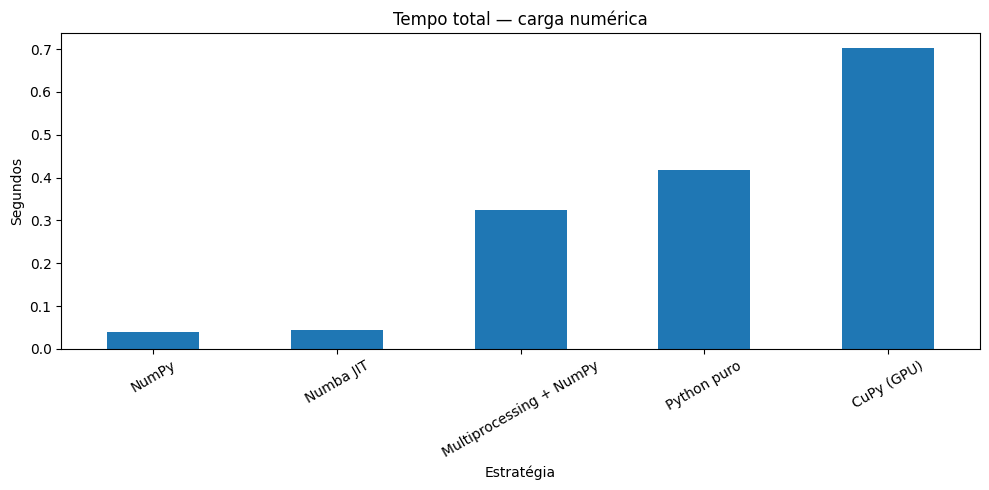

In [14]:

ax = numeric_df.sort_values("Total numérico (s)").plot(
    x="Estratégia",
    y="Total numérico (s)",
    kind="bar",
    figsize=(10, 5),
    legend=False,
    rot=30,
    title="Tempo total — carga numérica"
)
ax.set_ylabel("Segundos")
plt.tight_layout()
plt.show()

## Célula 15 — Gráfico de speedup numérico

Aqui a leitura fica mais intuitiva para discussão em sala:
- valor **1** = igual ao baseline
- maior que **1** = mais rápido que o baseline

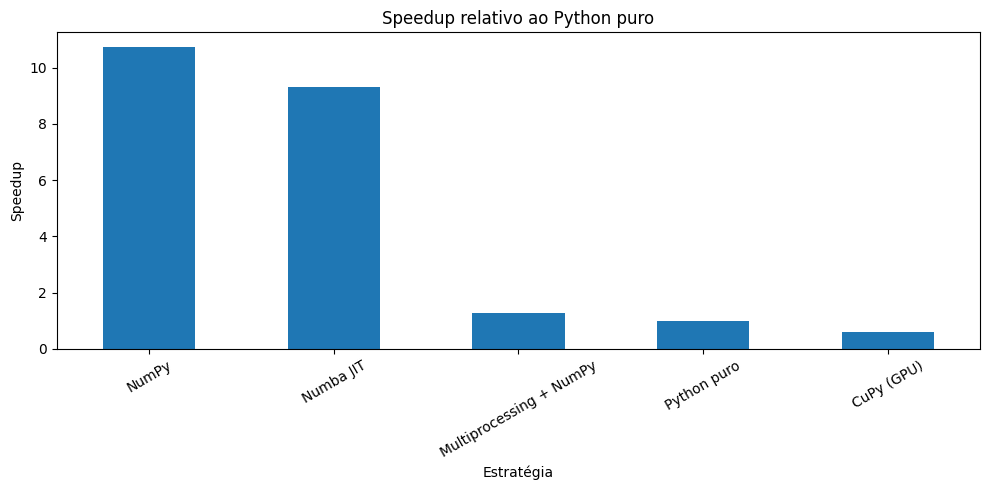

In [15]:

ax = numeric_df.sort_values("Speedup vs Python", ascending=False).plot(
    x="Estratégia",
    y="Speedup vs Python",
    kind="bar",
    figsize=(10, 5),
    legend=False,
    rot=30,
    title="Speedup relativo ao Python puro"
)
ax.set_ylabel("Speedup")
plt.tight_layout()
plt.show()

## Célula 16 — Interpretação didática dos resultados

### Leituras esperadas
1. **Python puro** tende a ser a referência mais lenta.
2. **NumPy** costuma ser muito forte em operações vetoriais simples.
3. **Numba JIT** pode competir fortemente quando queremos manter loops explícitos.
4. **Multiprocessing + NumPy** pode ganhar em cargas grandes, mas paga overhead de processos.
5. **CuPy** pode vencer bem em operações massivas, mas precisa compensar o custo de transferência CPU ↔ GPU.
6. **Hashing** mostra um caso importante fora de IA: aqui o ganho pode vir mais de CPU paralela do que de GPU.

### Conclusão arquitetural
A melhor estratégia depende do padrão da carga:
- **álgebra linear / vetores grandes** → NumPy, Numba ou GPU
- **tarefas independentes como hashing** → multiprocessing pode ser mais natural
- **cargas pequenas** → overhead pode matar o ganho teórico

> Em HPC e em IA, a pergunta correta não é “qual tecnologia é mais rápida?”,  
> e sim: **“qual arquitetura combina melhor com este padrão de computação?”**